In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar un estilo bonito para las gráficas (estilo artículo científico)
sns.set_theme(style="whitegrid", context="talk")

In [7]:
df_citic = pd.read_csv('resultados/q_citic.csv')
df_servidor = pd.read_csv('resultados/q_servidor.csv')
df_spark = pd.read_csv('resultados/q_spark.csv')

df_citic['Maquina'] = 'CITIC'
df_servidor['Maquina'] = 'Servidor'
df_spark['Maquina'] = 'Spark'

df = pd.concat([df_citic, df_servidor, df_spark], ignore_index=True)

display(df.head())

,Modelo,Motor,Hardware,Tarea,Numero de Problemas,Numero de Lotes,Tamaño Batch,Precisión,Energía (kWh),Energía (J),...,TTFT Medio (s),TPOT (s/token),Throughput Decode (tok/s),Throughput Total (tok/s),Inferencia Media (s),Energía (J/token gen),Cuantizacion,Attention Implementation,Speculative Decoding,Maquina
0,Qwen/Qwen2.5-Coder-3B-Instruct-GGUF/qwen2.5-co...,llamacpp,cuda,humaneval,164,164,1,71.951220,0.023656,85163.117238,...,0.127558,0.041304,24.210817,136.266720,2.784353,8.073099,f16,NaN,NaN,CITIC
1,Qwen/Qwen2.5-Coder-3B-Instruct-GGUF/qwen2.5-co...,llamacpp,cuda,mmlu,1140,1140,1,57.368421,0.006986,25150.401325,...,0.089252,0.040827,24.493447,1158.356830,0.130079,22.061756,f16,NaN,NaN,CITIC
2,Qwen/Qwen2.5-Coder-3B-Instruct-GGUF/qwen2.5-co...,llamacpp,cuda,resumen,100,100,1,26.269395,0.018327,65975.868426,...,0.723706,0.040626,24.614729,250.593313,4.078201,7.990295,f16,NaN,NaN,CITIC
3,Qwen/Qwen2.5-Coder-3B-Instruct-GGUF/qwen2.5-co...,llamacpp,cuda,humaneval,164,164,1,71.341463,0.013296,47863.803794,...,0.113141,0.025372,39.412928,213.352652,1.785862,4.426915,q8_0,NaN,NaN,CITIC
4,Qwen/Qwen2.5-Coder-3B-Instruct-GGUF/qwen2.5-co...,llamacpp,cuda,mmlu,1140,1140,1,57.456140,0.005251,18902.537475,...,0.076586,0.025051,39.918648,1482.506249,0.101637,16.581173,q8_0,NaN,NaN,CITIC


In [8]:
df.info()

# Ver un resumen estadístico (medias, máximos, mínimos de tus mediciones)
display(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Modelo                     324 non-null    str    
 1   Motor                      324 non-null    str    
 2   Hardware                   324 non-null    str    
 3   Tarea                      324 non-null    str    
 4   Numero de Problemas        324 non-null    int64  
 5   Numero de Lotes            324 non-null    int64  
 6   Tamaño Batch               324 non-null    int64  
 7   Precisión                  324 non-null    float64
 8   Energía (kWh)              324 non-null    float64
 9   Energía (J)                324 non-null    float64
 10  CO2 (kg)                   324 non-null    float64
 11  EDP (J*s)                  324 non-null    float64
 12  Tokens Prompt              324 non-null    int64  
 13  Tokens Generados           324 non-null    int64  
 14  TTFT 

,Numero de Problemas,Numero de Lotes,Tamaño Batch,Precisión,Energía (kWh),Energía (J),CO2 (kg),EDP (J*s),Tokens Prompt,Tokens Generados,TTFT Medio (s),TPOT (s/token),Throughput Decode (tok/s),Throughput Total (tok/s),Inferencia Media (s),Energía (J/token gen),Attention Implementation,Speculative Decoding
count,324.000000,324.000000,324.0,324.000000,324.000000,324.000000,324.000000,3.240000e+02,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,0.0,0.0
mean,388.500000,388.500000,1.0,40.032808,0.021521,77475.338989,0.002848,1.463262e+08,79177.666667,19820.805556,0.382199,0.024403,58.858400,716.868746,3.917546,5.352716,NaN,NaN
std,435.202622,435.202622,0.0,22.286218,0.030782,110815.990246,0.004371,5.873098e+08,56728.042456,16493.431745,1.557331,0.019983,29.155206,1072.338719,5.963458,10.572113,NaN,NaN
min,100.000000,100.000000,1.0,0.609756,0.000767,2759.935855,0.000114,1.081927e+05,8478.000000,1140.000000,0.018770,0.008297,7.187196,7.272206,0.034335,0.603726,NaN,NaN
25%,137.500000,137.500000,1.0,23.128775,0.004502,16208.981048,0.000406,2.015925e+06,34557.000000,8253.500000,0.037541,0.011632,35.715136,103.214402,0.687650,1.645504,NaN,NaN
50%,157.000000,157.000000,1.0,42.184211,0.010646,38325.636952,0.001072,1.281866e+07,74233.000000,13056.500000,0.074942,0.019212,52.050992,273.123694,2.109703,3.189763,NaN,NaN
75%,408.000000,408.000000,1.0,57.763158,0.025748,92691.474136,0.003027,6.719673e+07,109232.250000,33571.250000,0.226499,0.028000,85.966225,755.925046,4.867795,5.784586,NaN,NaN
max,1140.000000,1140.000000,1.0,76.666667,0.212106,763581.541567,0.033269,6.377997e+09,173830.000000,69893.000000,23.269967,0.139136,120.530903,4470.169539,52.737778,156.789173,NaN,NaN


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

def limpiar_modelo(nombre):
    nombre = str(nombre).lower()
    if 'qwen' in nombre: return 'Qwen'
    if 'gemma' in nombre: return 'Gemma'
    if 'mistral' in nombre: return 'Mistral'
    return nombre

df_citic = pd.read_csv('resultados/q_citic.csv')
df_servidor = pd.read_csv('resultados/q_servidor.csv')
df_spark = pd.read_csv('resultados/q_spark.csv')

df_citic['Familia'] = df_citic['Modelo'].apply(limpiar_modelo)
df_servidor['Familia'] = df_servidor['Modelo'].apply(limpiar_modelo)
df_spark['Familia'] = df_spark['Modelo'].apply(limpiar_modelo)

df_citic['Maquina'] = 'CITIC'
df_servidor['Maquina'] = 'Servidor'
df_spark['Maquina'] = 'Spark'
df_total = pd.concat([df_citic, df_servidor, df_spark], ignore_index=True)

df_total.to_csv("resultados/total_limpio.csv")


In [19]:
datos_graficar = [
    (df_citic, 'CITIC'),
    (df_servidor, 'Servidor sobremesa'),
    (df_spark, 'Spark')
]

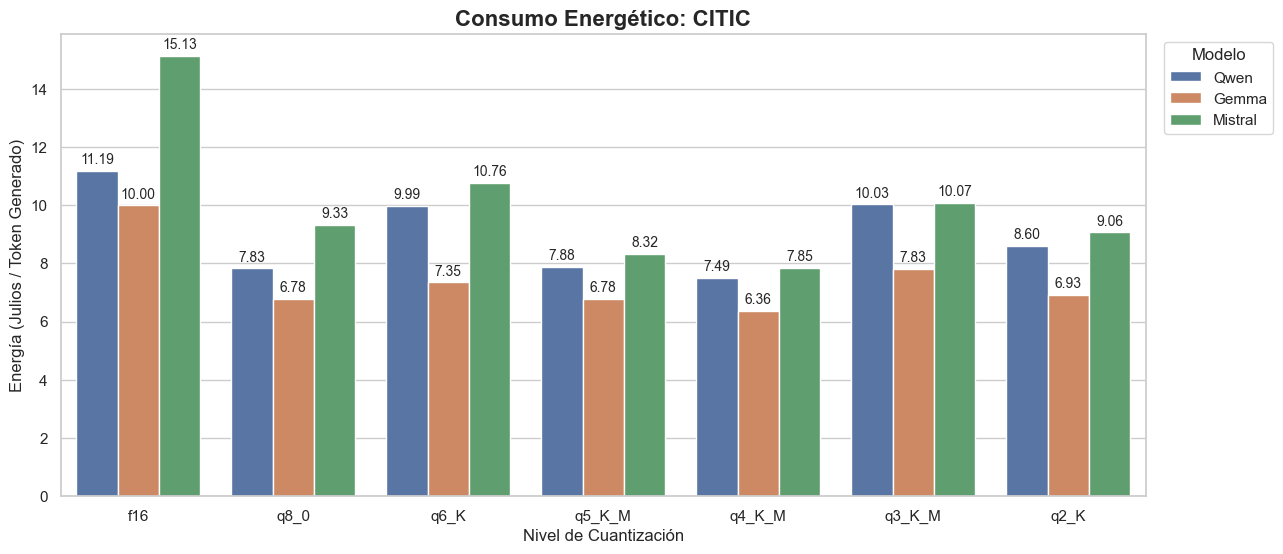

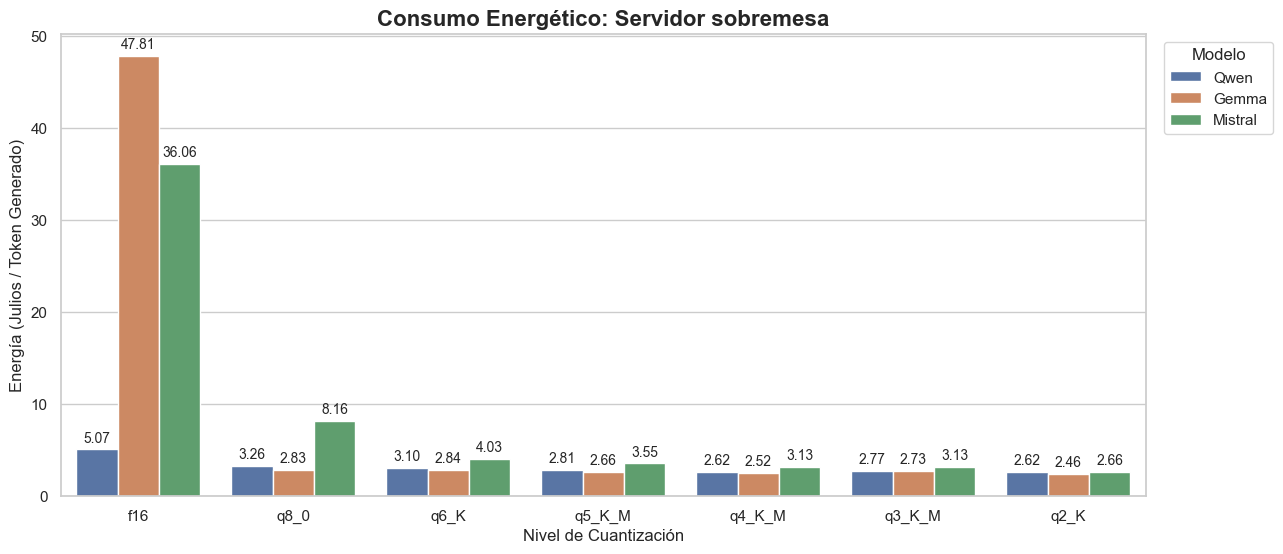

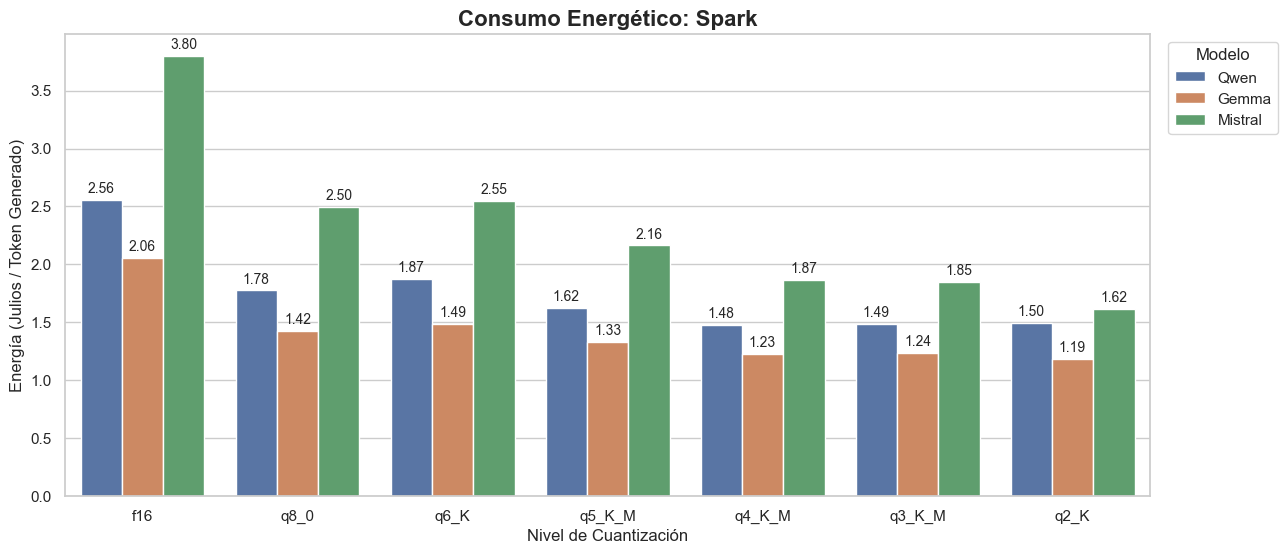

In [25]:
orden_q = ["f16", 'q8_0', 'q6_K', 'q5_K_M', 'q4_K_M', 'q3_K_M', 'q2_K']
for df_actual, titulo in datos_graficar:
    plt.figure(figsize=(14, 6))
    
    # Filtramos para que solo muestre las cuantizaciones que existen en este dataframe concreto
    
    
    ax = sns.barplot(
        data=df_actual,
        x='Cuantizacion',
        y='Energía (J/token gen)',
        hue='Familia',
        order=orden_q,
        errorbar=None  # Quita la raya estadística para dejar 3 barras limpias
    )
    for container in ax.containers:
        # Añadimos el texto. fmt='%.2f' significa que muestre 2 decimal.
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)
    
    # Textos
    plt.title(f'Consumo Energético: {titulo}', fontsize=16, fontweight='bold')
    plt.ylabel('Energía (Julios / Token Generado)')
    plt.xlabel('Nivel de Cuantización')
    plt.legend(title='Modelo', bbox_to_anchor=(1.01, 1), loc='upper left')
    
    plt.show()

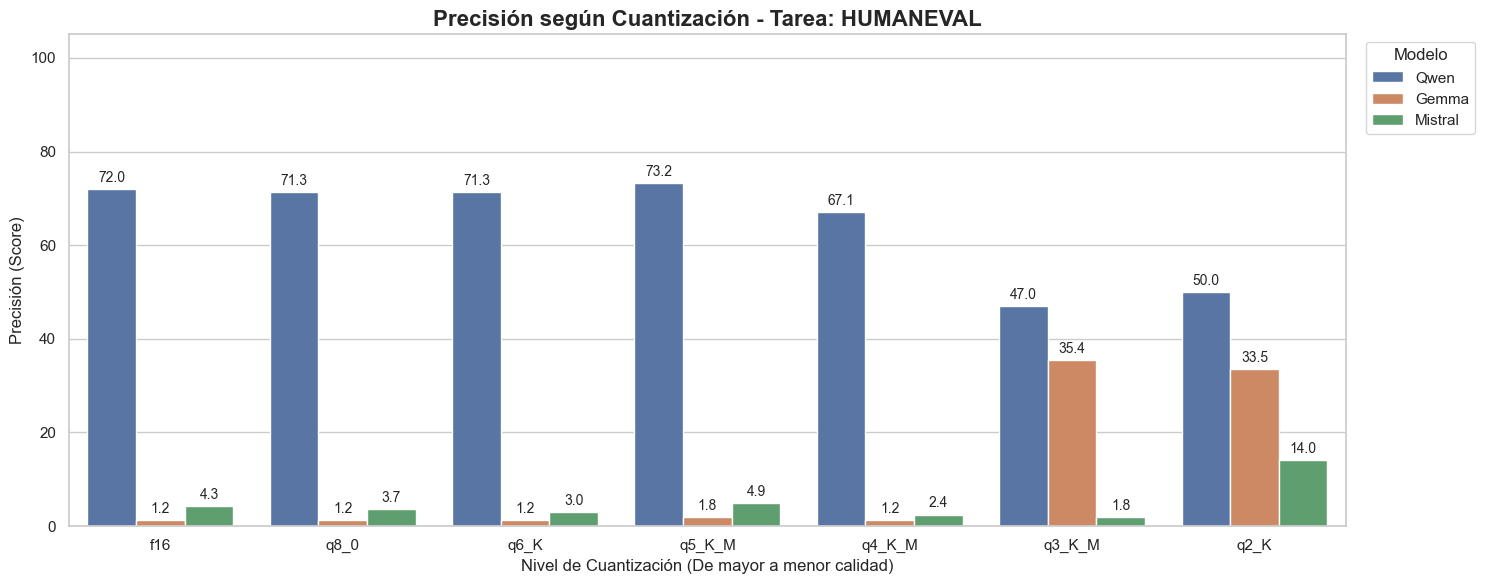

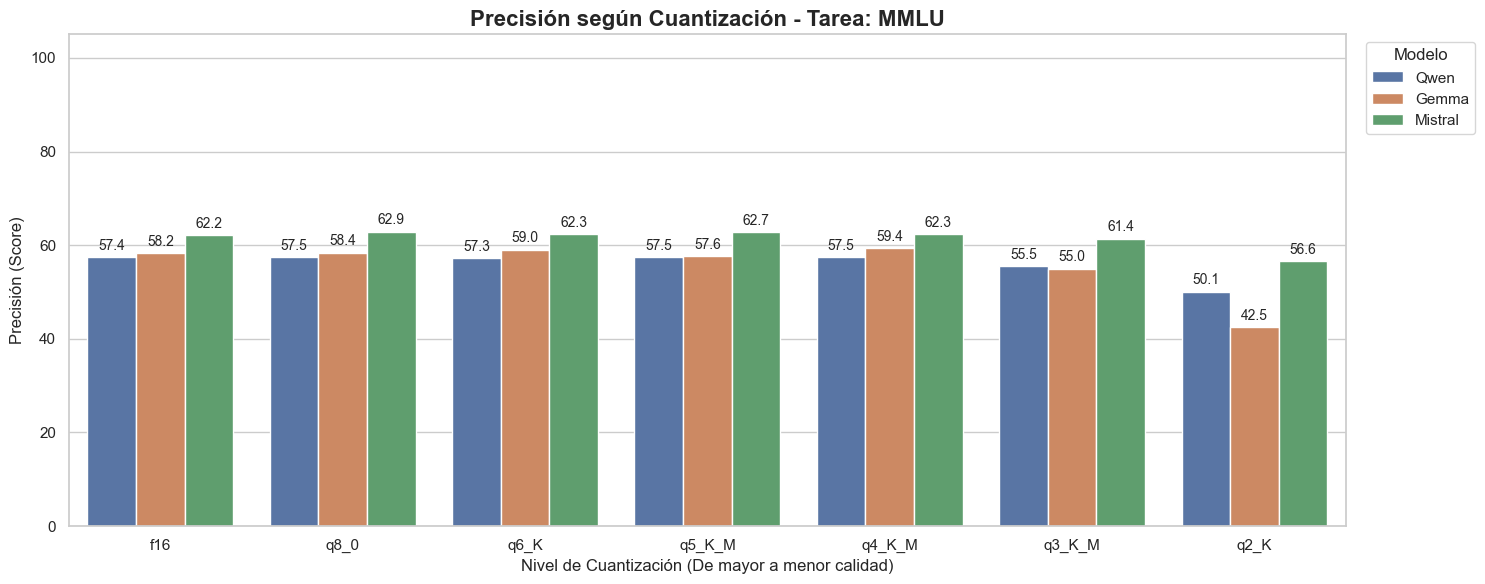

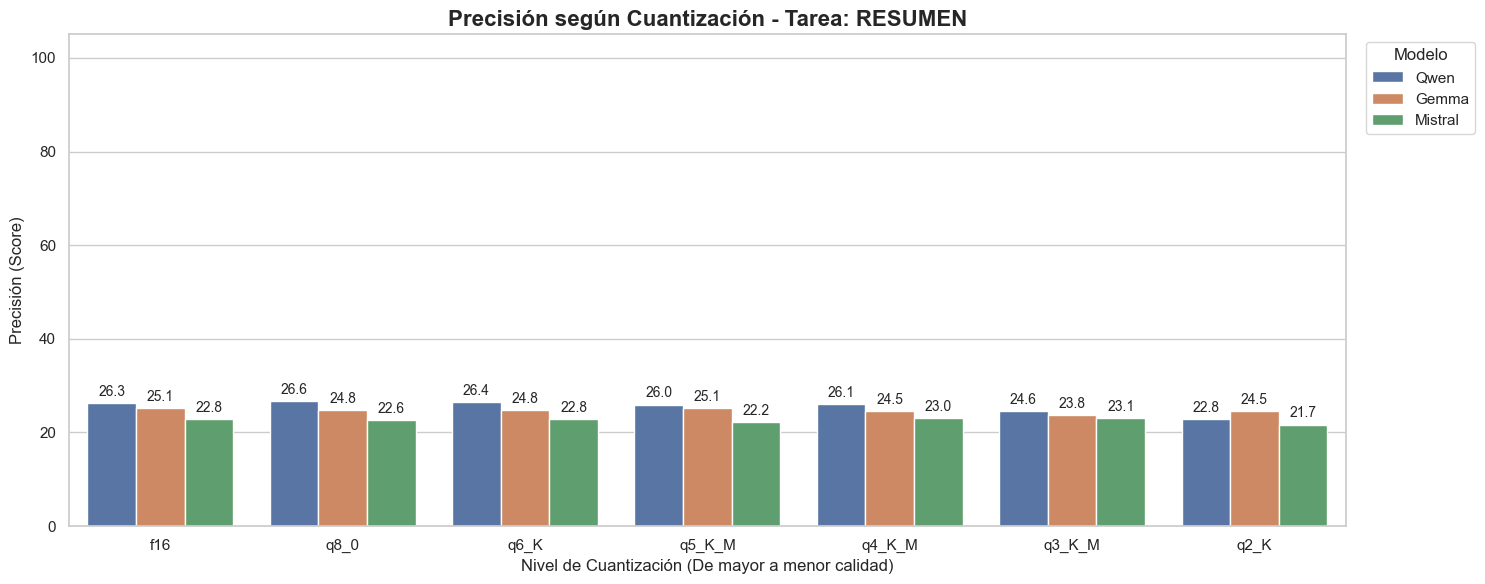

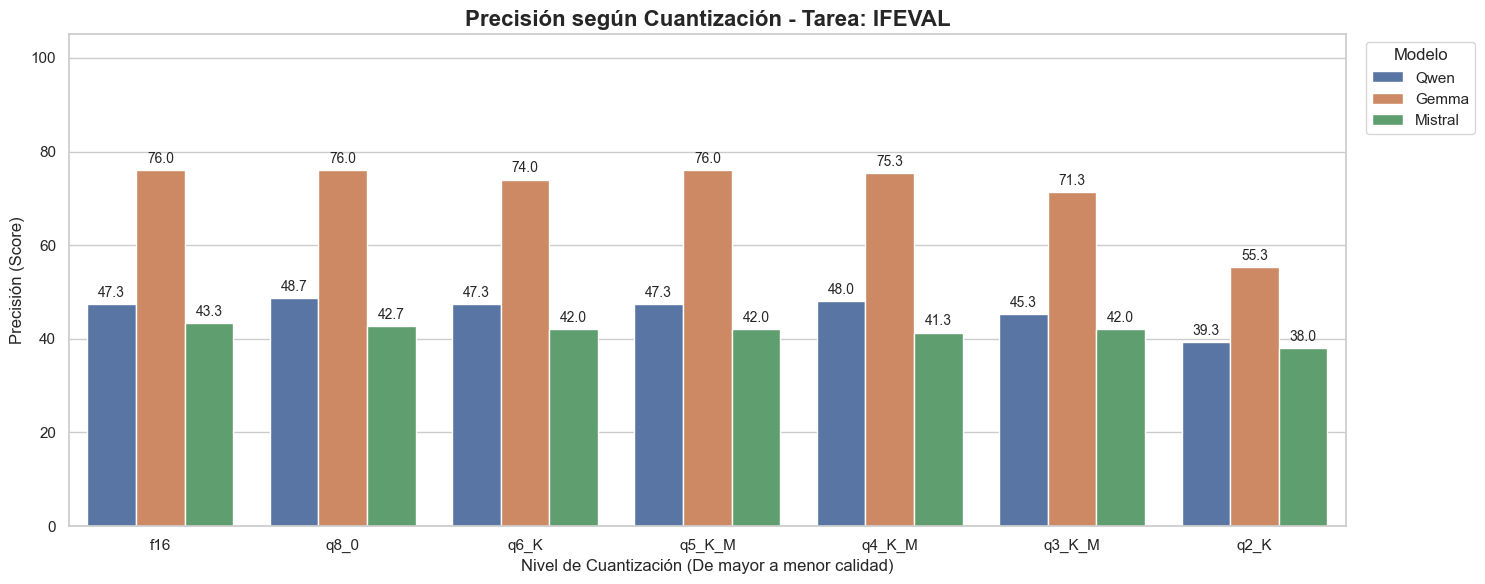

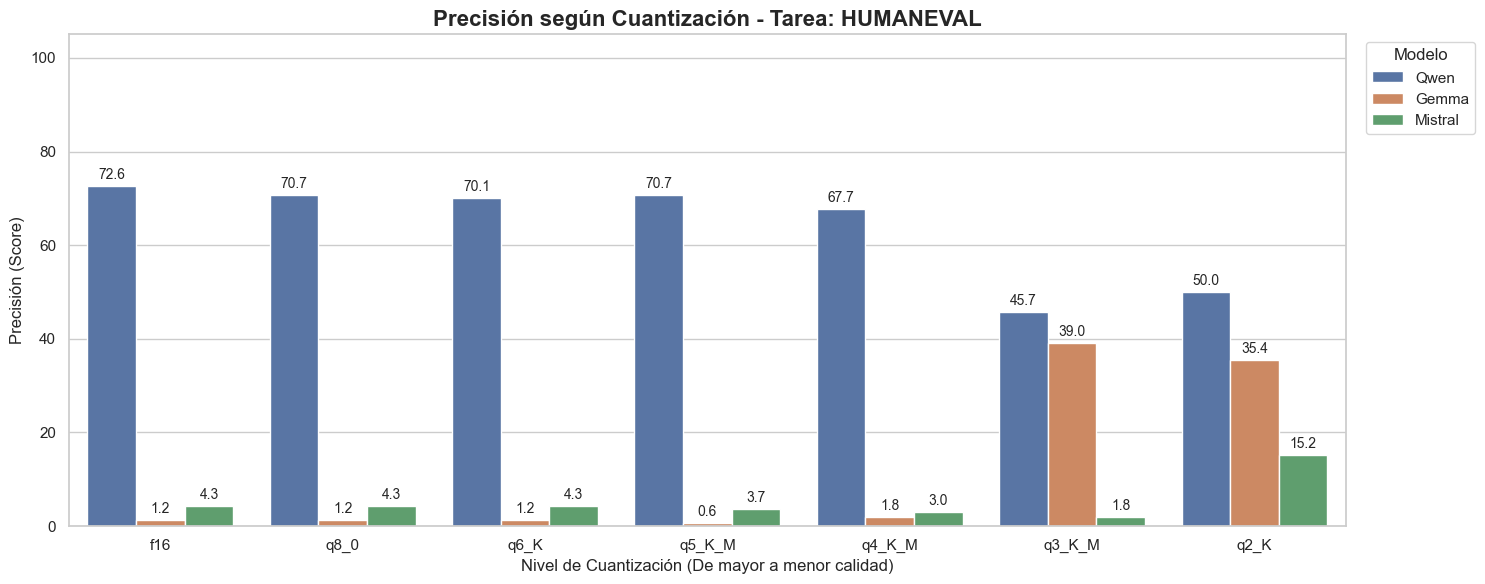

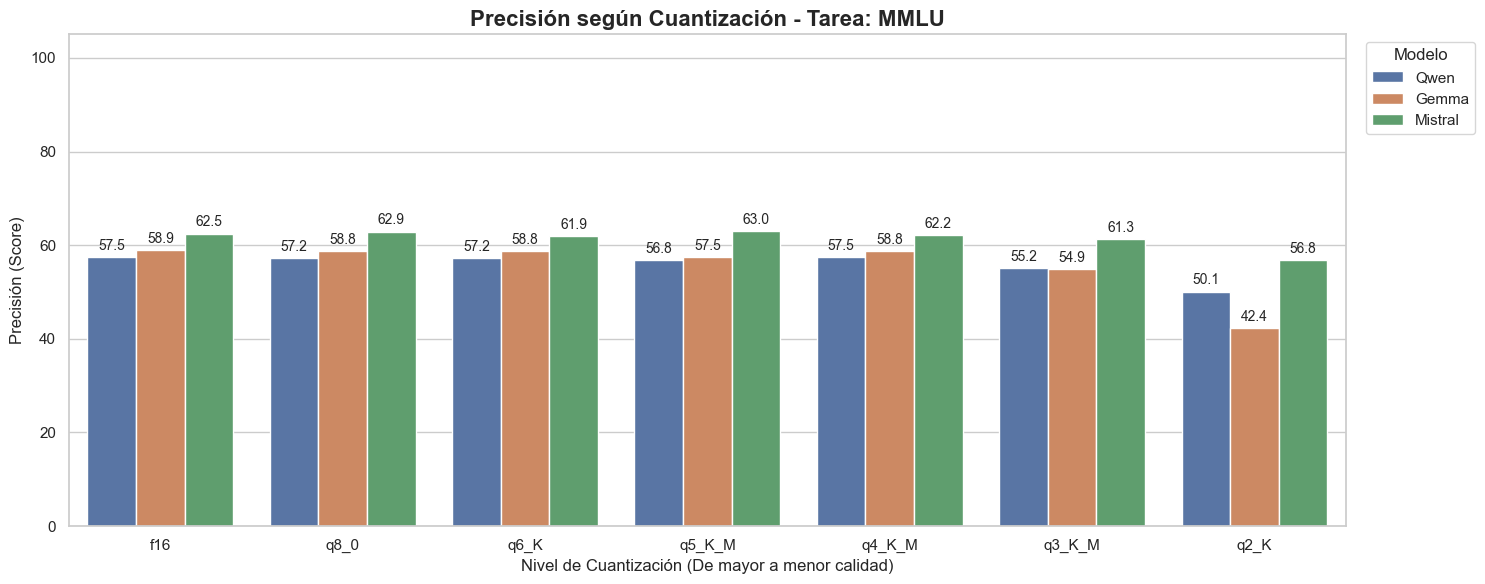

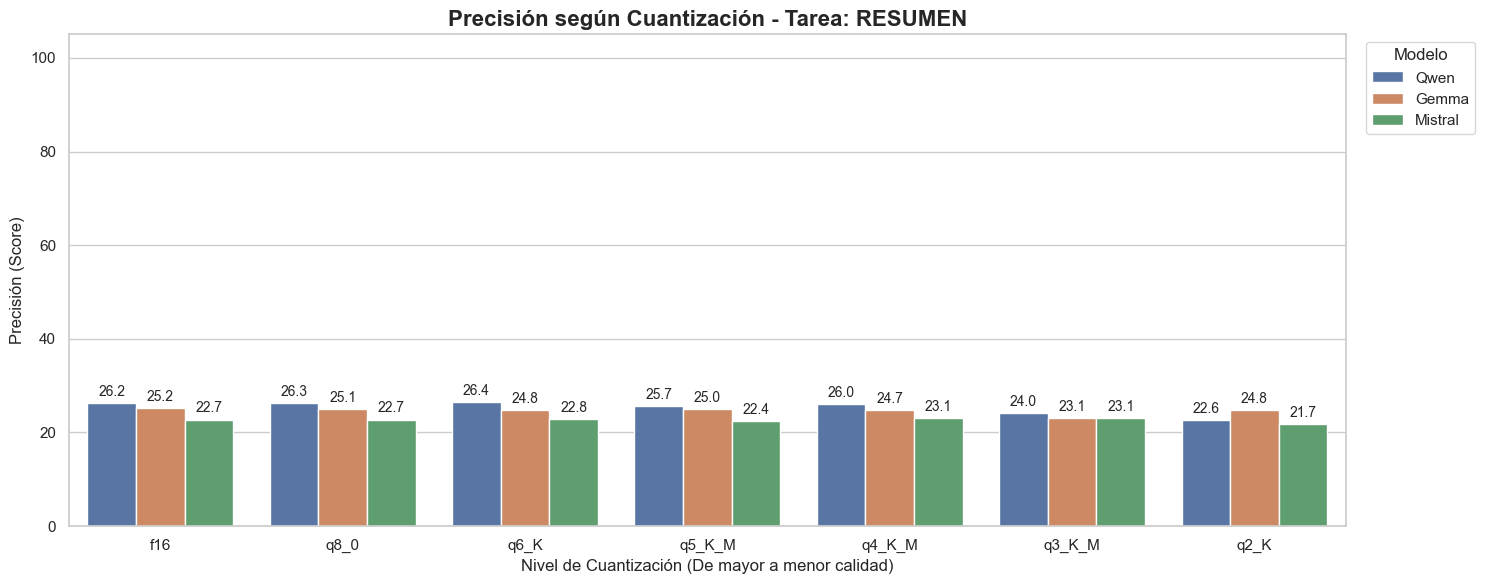

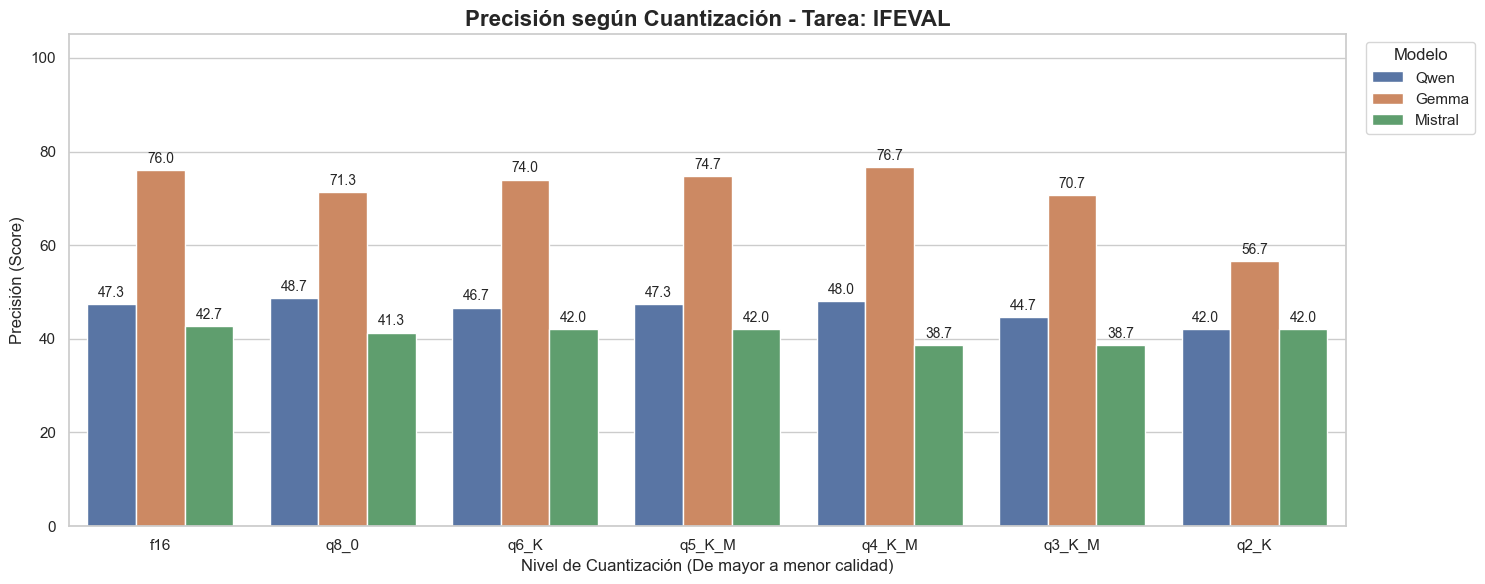

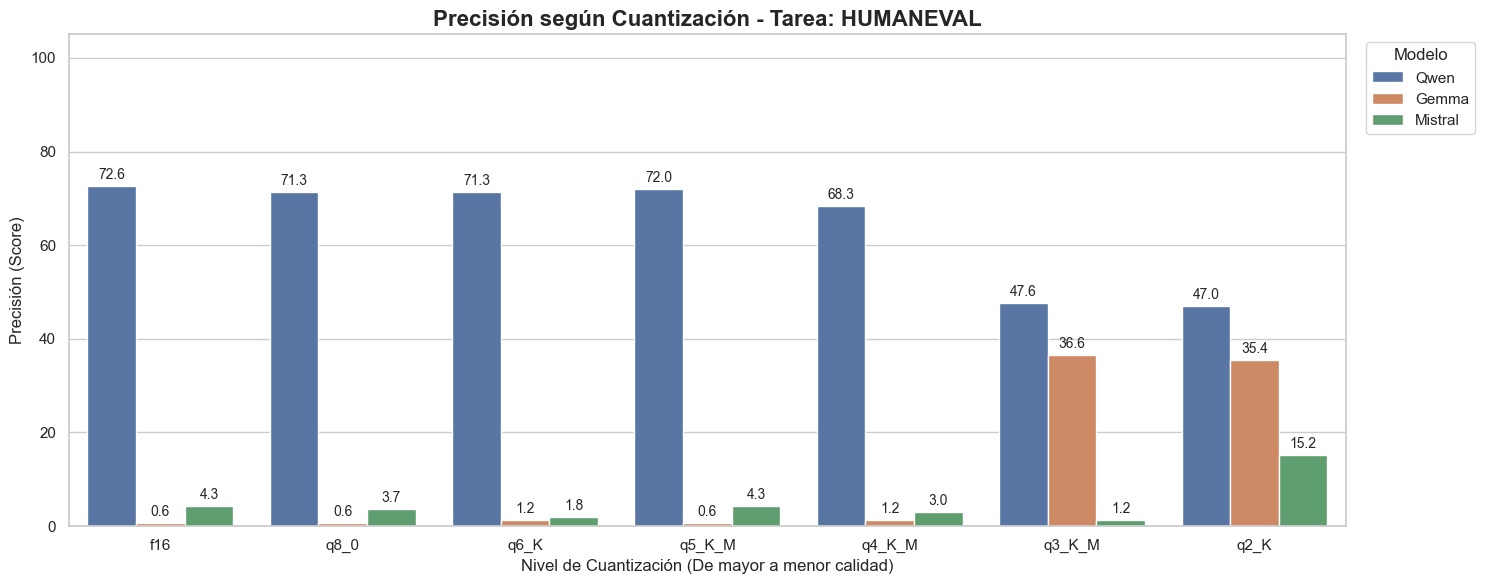

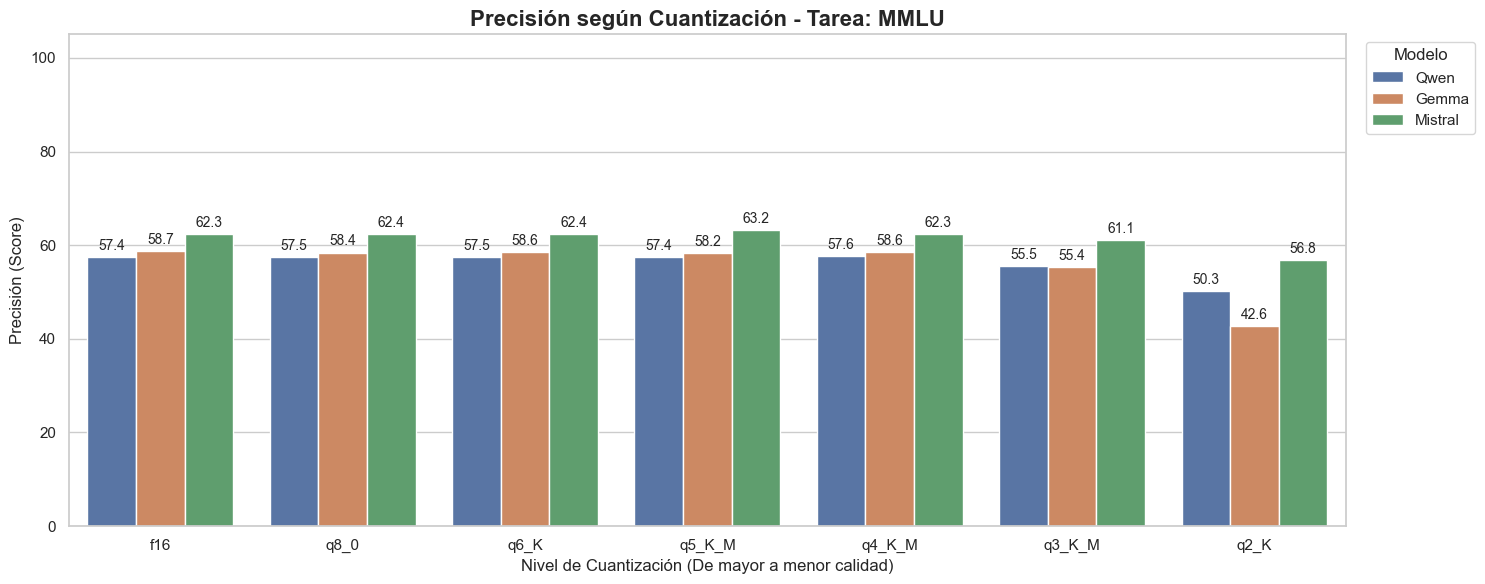

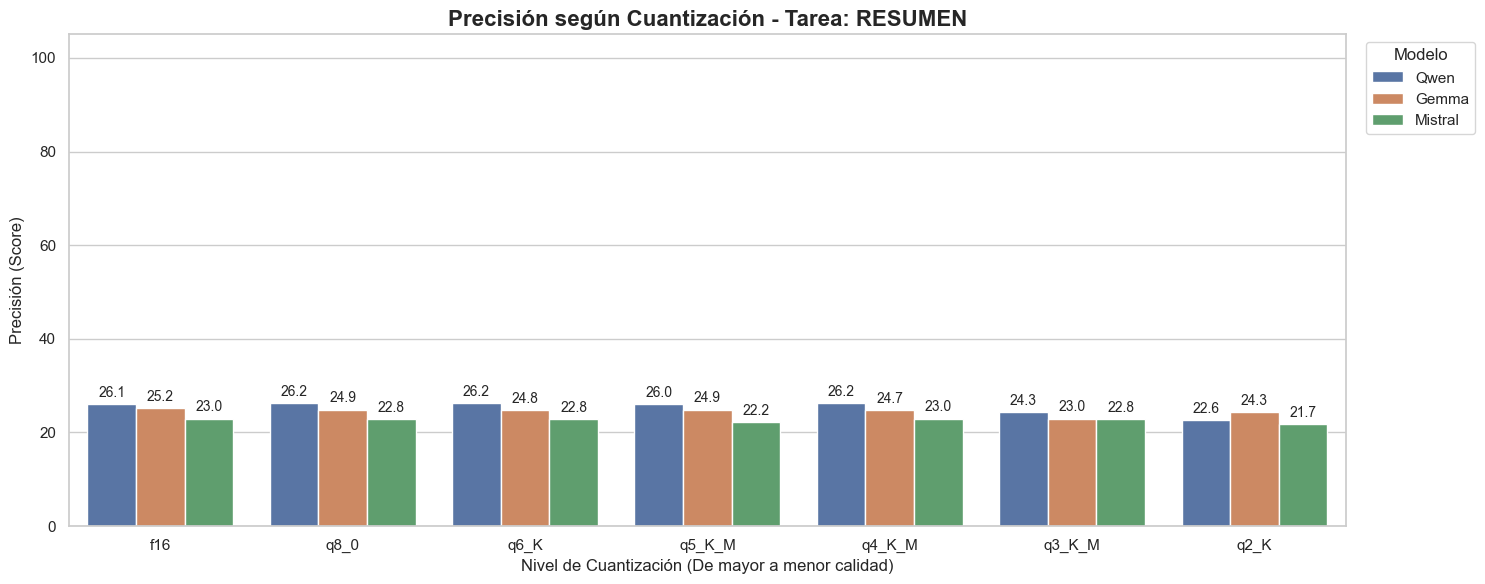

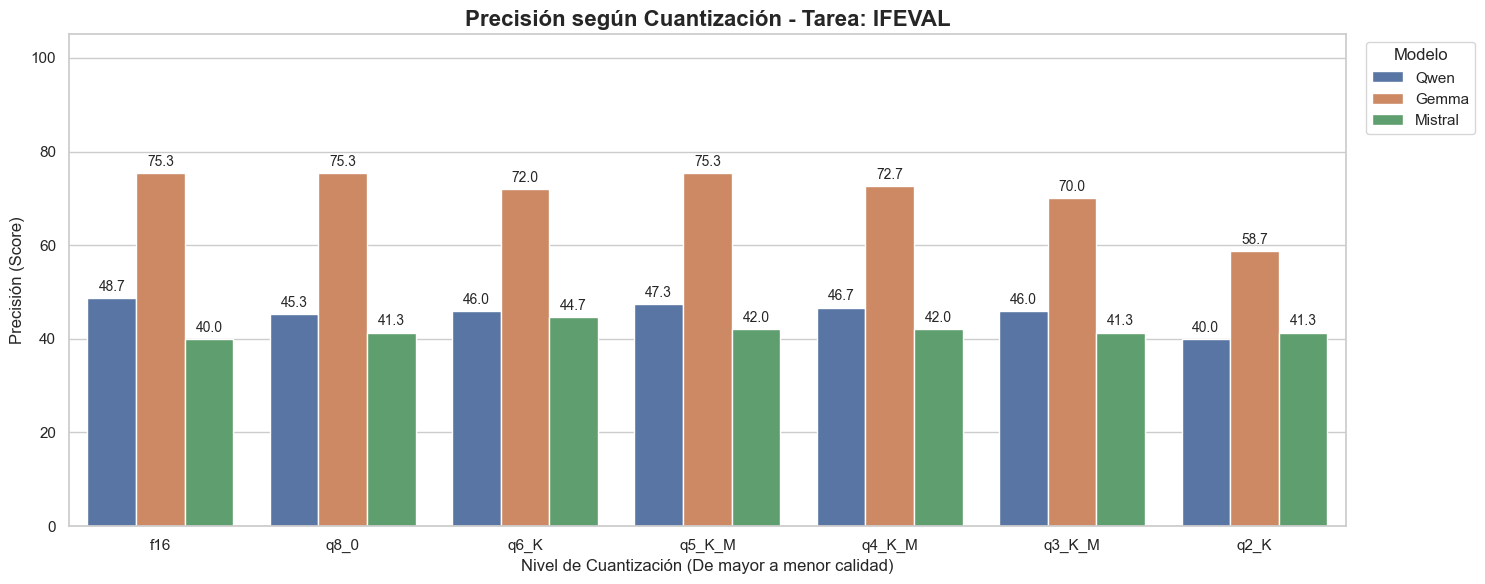

In [26]:
orden_q = ["f16", 'q8_0', 'q6_K', 'q5_K_M', 'q4_K_M', 'q3_K_M', 'q2_K']
tareas = df['Tarea'].unique()
for df_actual, titulo in datos_graficar:
    for tarea in tareas:
    # Filtramos los datos solo para esta tarea
        df_tarea = df_actual[df_actual['Tarea'] == tarea]
        
        plt.figure(figsize=(15, 6))
        
        # Dibujamos las barras y guardamos el gráfico en la variable 'ax'
        ax = sns.barplot(
            data=df_tarea,
            x='Cuantizacion',
            y='Precisión',
            hue='Familia',
            order=orden_q,
            errorbar=None
        )
        
        # =================================================================
        # EL TRUCO PARA VER EL NÚMERO EXACTO: ax.bar_label
        # =================================================================
        # Recorremos cada grupo de barras (Qwen, Gemma, Mistral)
        for container in ax.containers:
            # Añadimos el texto. fmt='%.1f' significa que muestre 1 decimal.
            ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)
            
        plt.title(f'Precisión según Cuantización - Tarea: {tarea.upper()}', fontsize=16, fontweight='bold')
        plt.xlabel('Nivel de Cuantización (De mayor a menor calidad)')
        plt.ylabel('Precisión (Score)')
        
        # Ponemos el límite Y hasta 100 si son porcentajes para que la escala sea igual en todas
        # (Si alguna tarea supera 100, comenta la siguiente línea)
        plt.ylim(0, 105) 
        
        plt.legend(title='Modelo', bbox_to_anchor=(1.01, 1), loc='upper left')
        plt.tight_layout()
        plt.show()